# Module 02: Autograd

## Introduction

The magic that makes neural networks trainable. Automatic
differentiation computes gradients through any computation - the
foundation of backpropagation.

**Autograd** (automatic differentiation) is how we compute gradients
automatically. When you do `loss.backward()` in PyTorch, autograd
figures out how to adjust every parameter to reduce the loss.

Why is this essential for LLMs?

-   **Millions of parameters**: An LLM has millions (or billions) of
    numbers to adjust. We can’t compute gradients by hand.
-   **Complex computations**: Attention, embeddings, layer norms - the
    gradient must flow through all of them.
-   **Training loop**: Every training step computes gradients to update
    weights.

Without autograd, deep learning wouldn’t be practical.

## Intuition: The Computational Graph

Every computation builds a **directed acyclic graph (DAG)** dynamically
as operations execute. This is called “define-by-run” - the graph
structure is determined by the actual code path taken, which can differ
each forward pass (useful for control flow like conditionals and loops).

Think of a computation as a graph of operations:

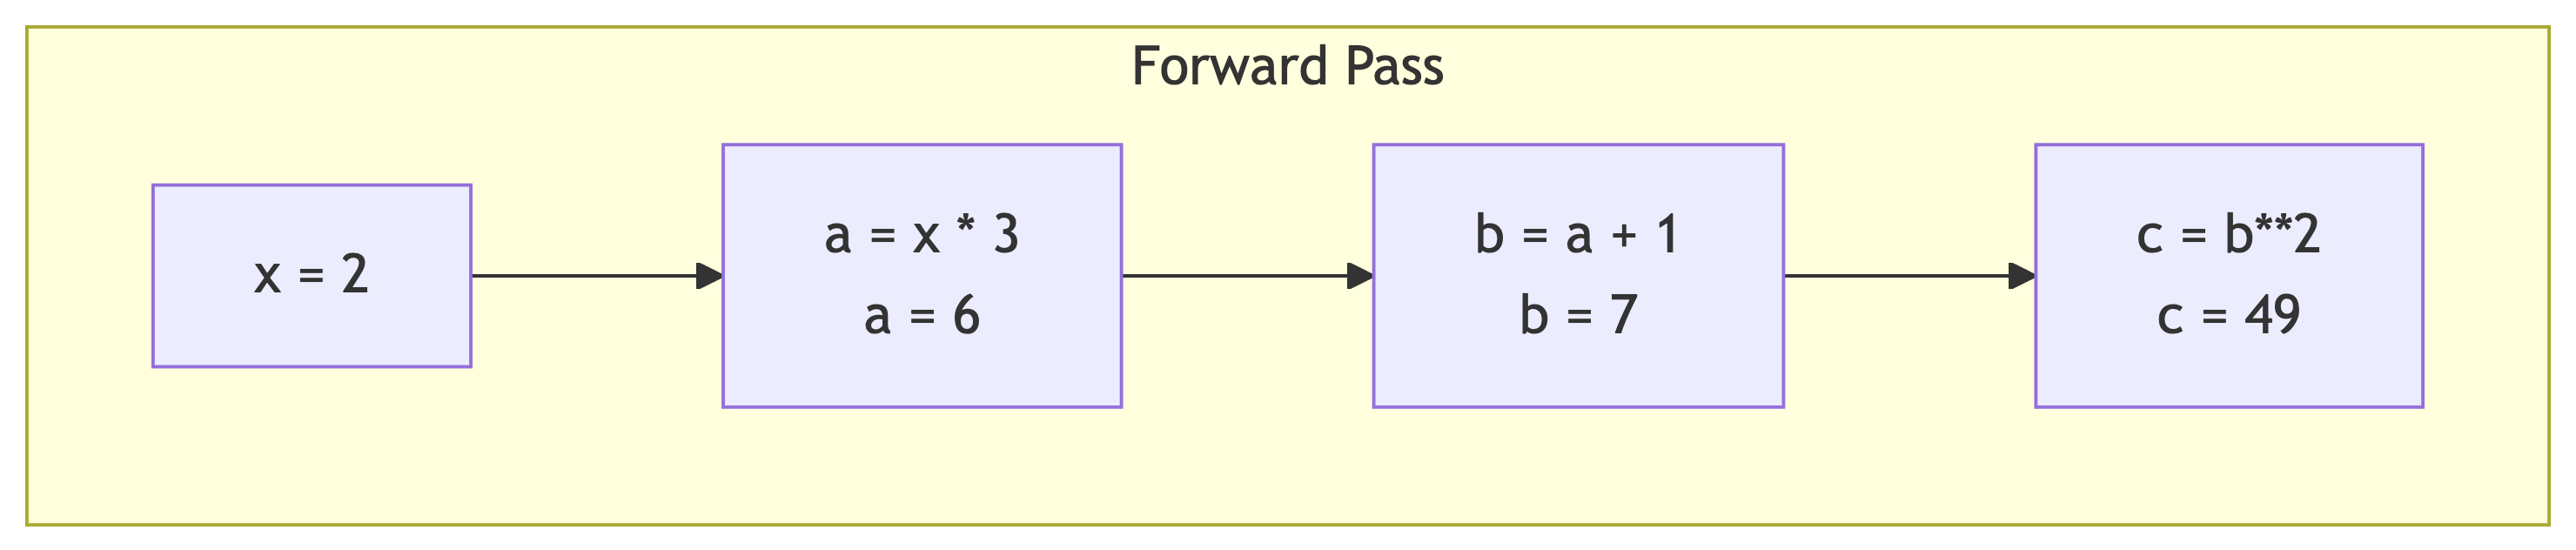

**Forward pass**: Compute values flowing down (x -\> a -\> b -\> c)

**Backward pass**: Compute gradients flowing up (c -\> b -\> a -\> x)

-   dc/dc = 1 (output gradient is always 1)
-   dc/db = 2b = 14 (derivative of b^2)
-   dc/da = dc/db x db/da = 14 x 1 = 14
-   dc/dx = dc/da x da/dx = 14 x 3 = 42

The **chain rule** connects everything: multiply local gradients as you
go back.

## Computational Graph: Forward and Backward

Here’s a more detailed example showing both passes:

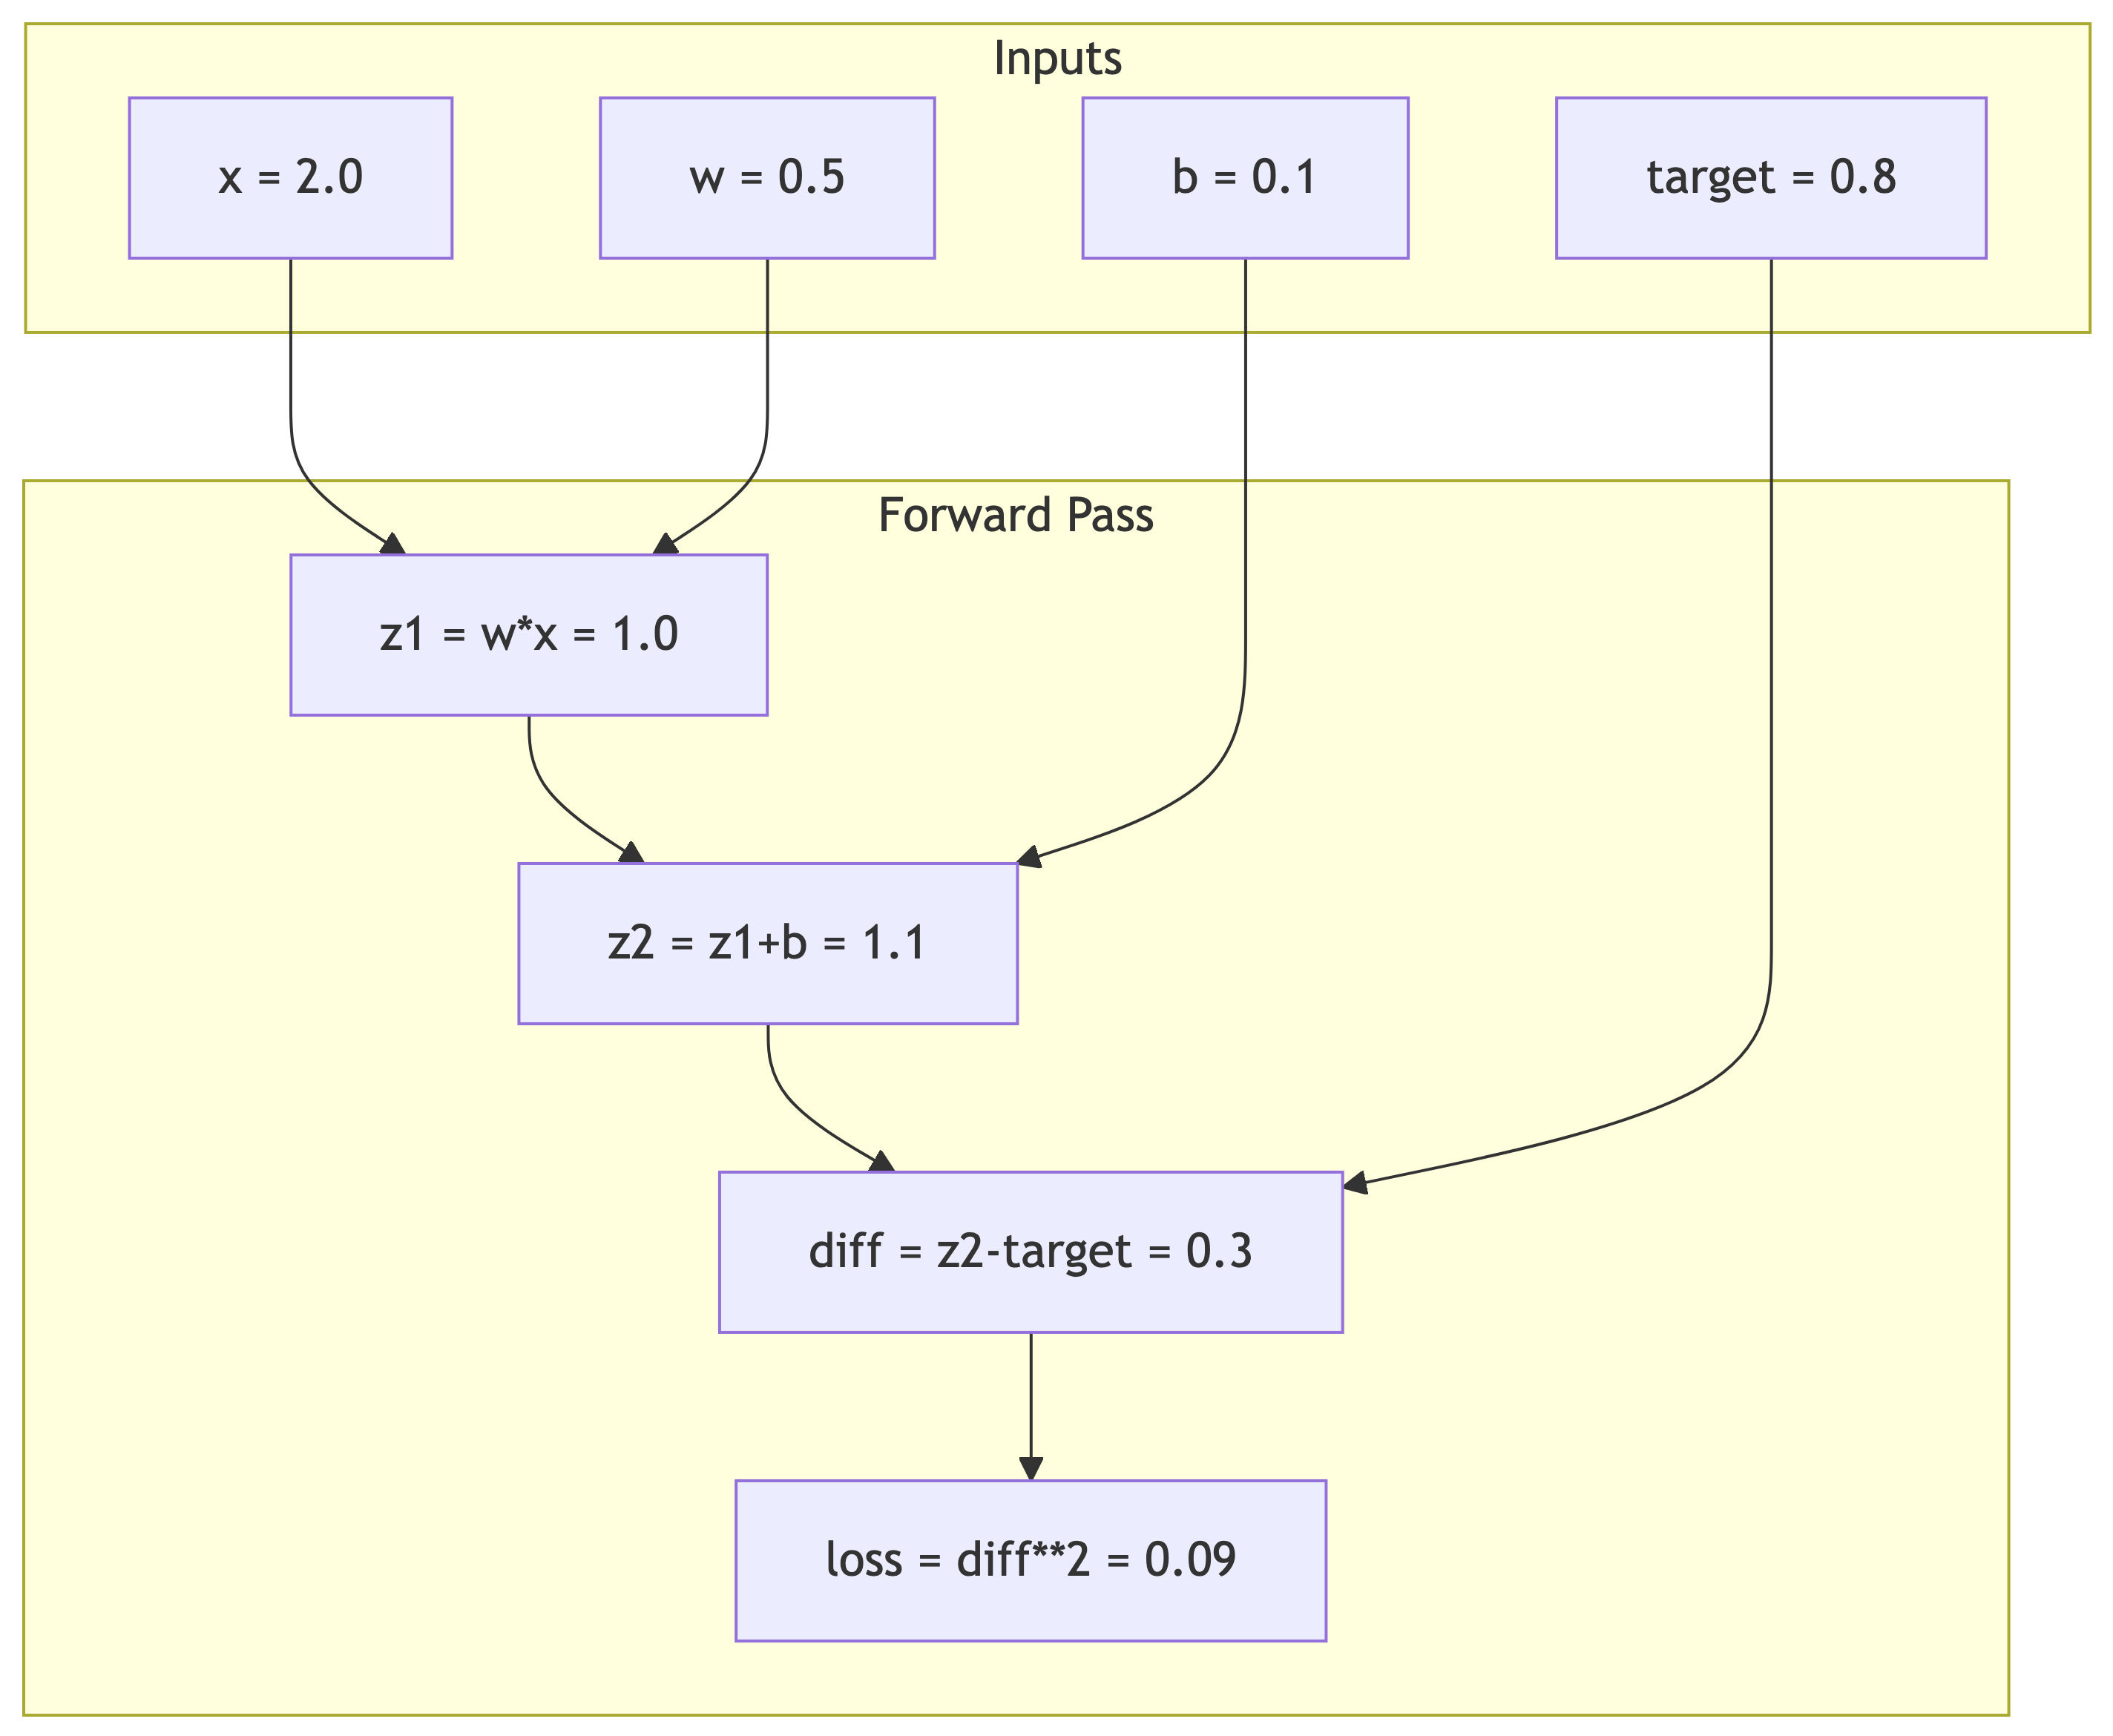

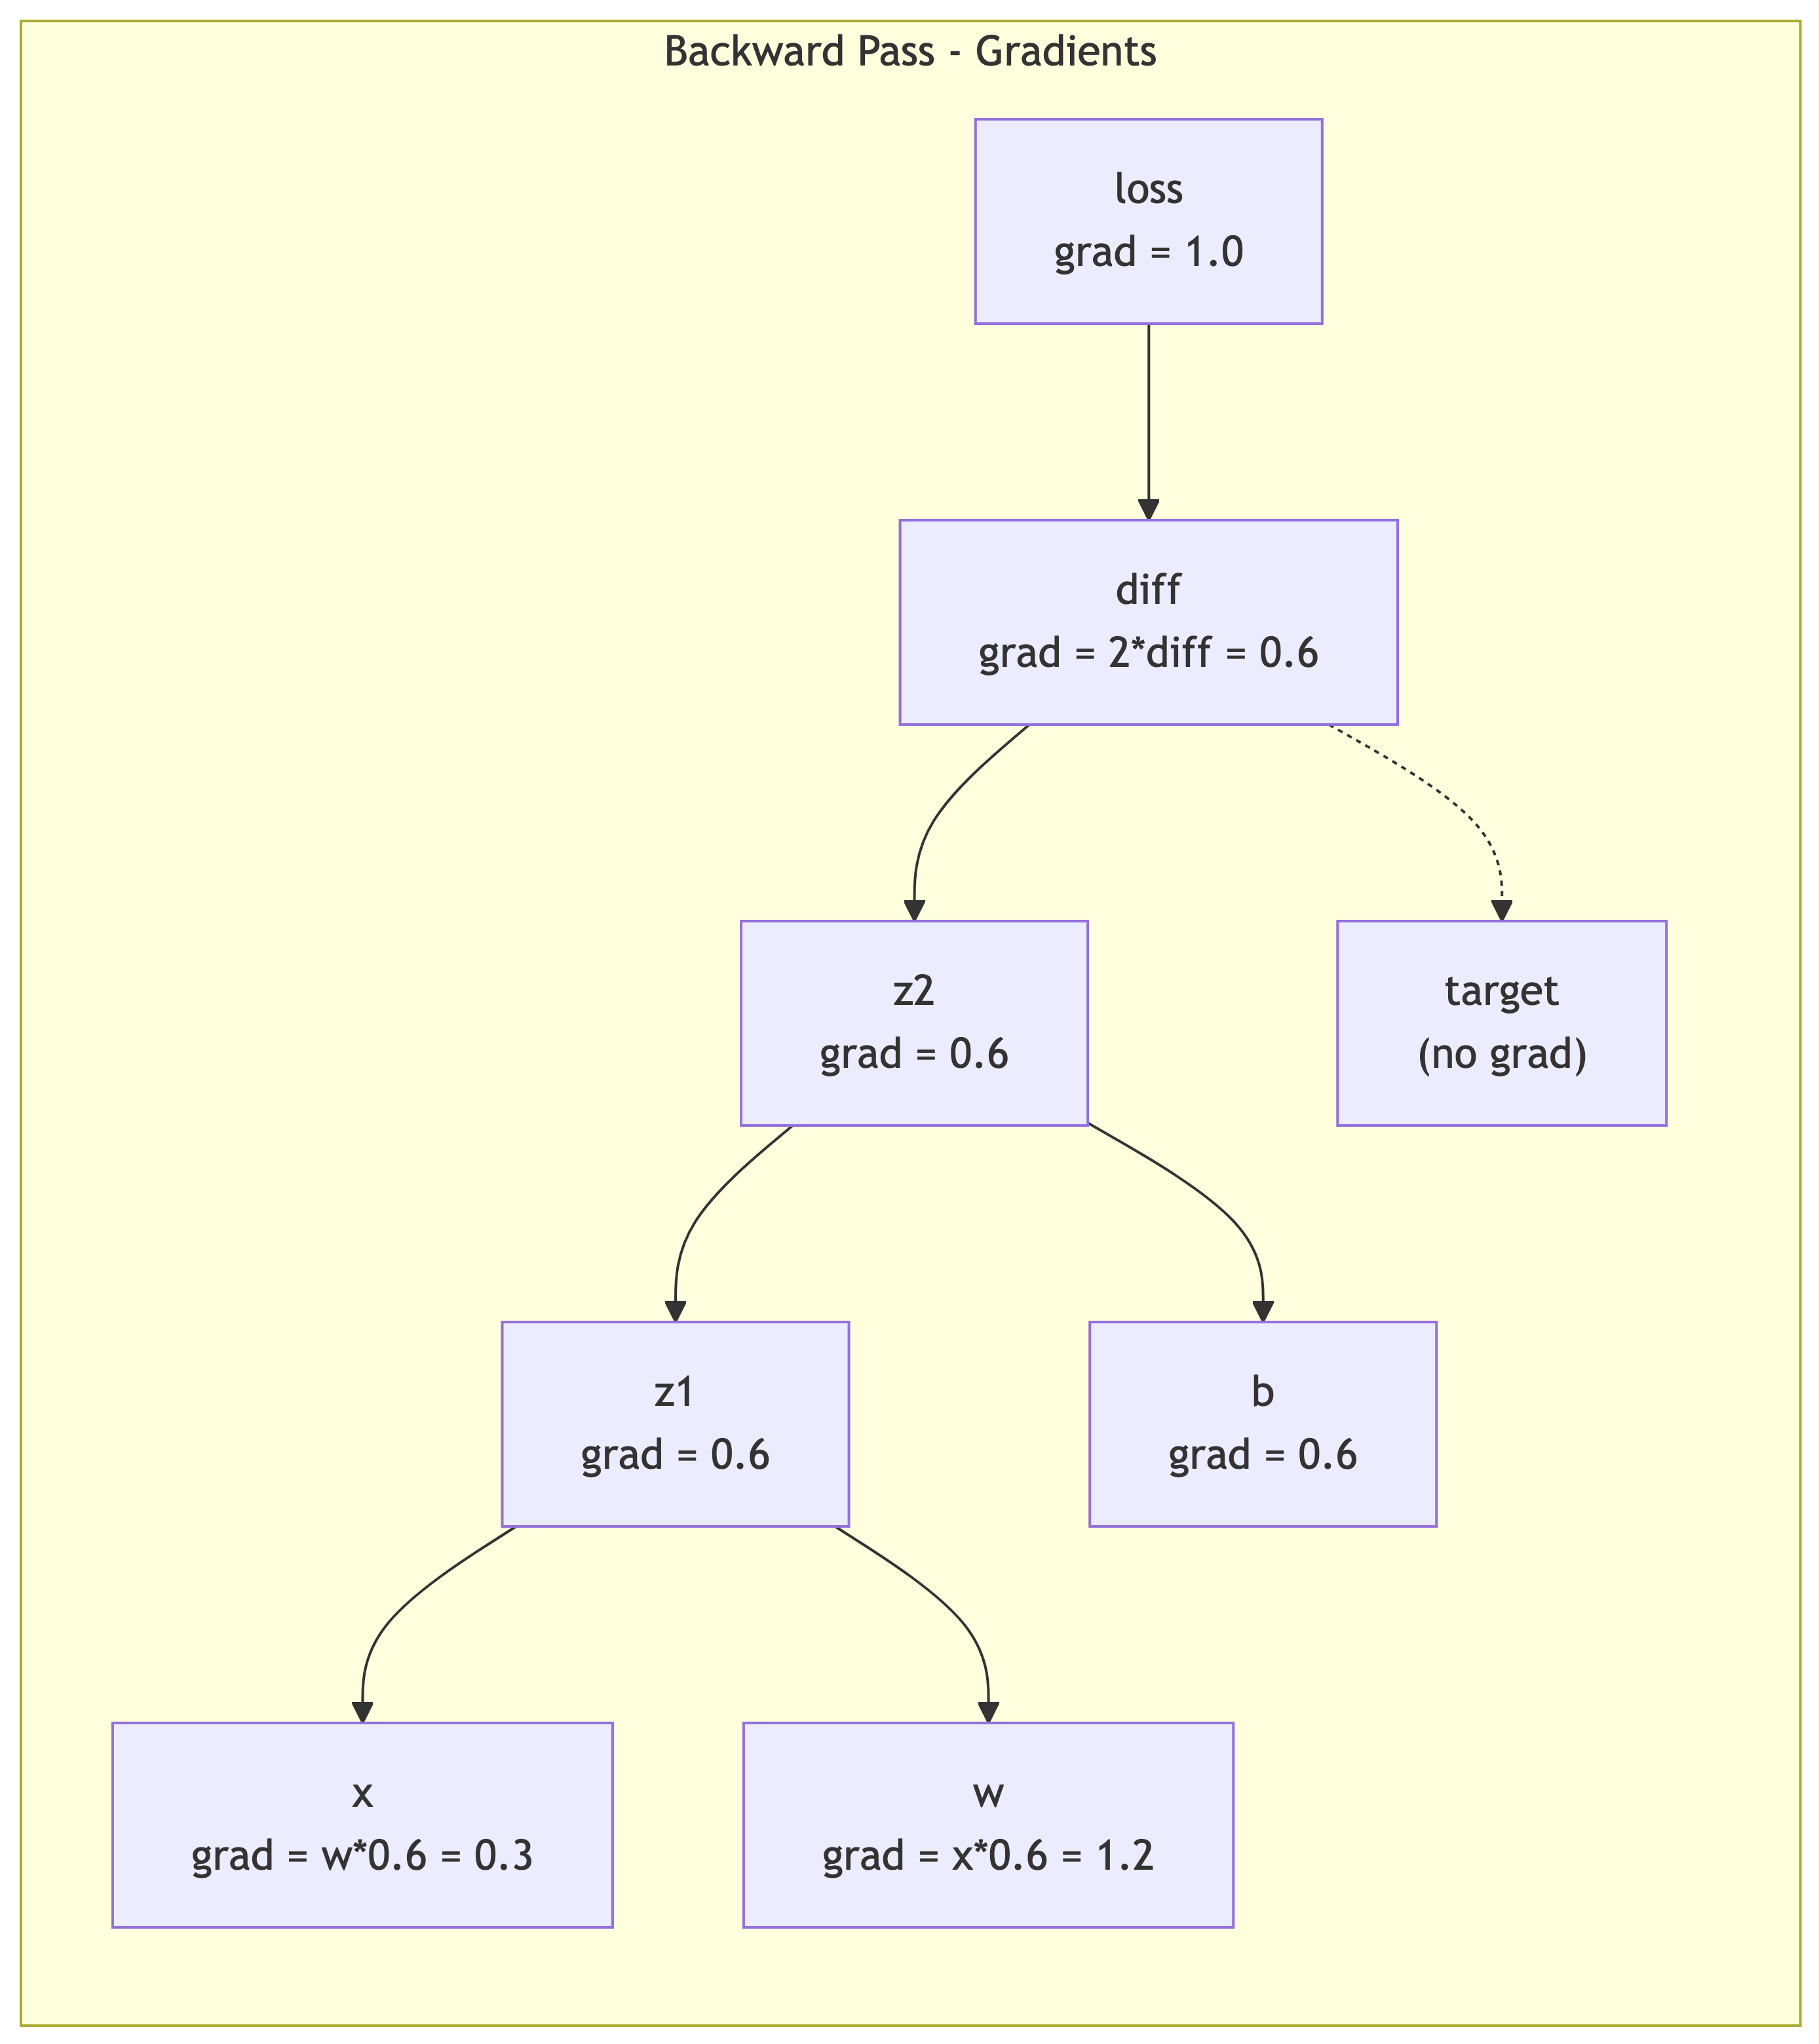

## The Math

### Chain Rule

For composed functions f(g(x)):

    d/dx[f(g(x))] = f'(g(x)) x g'(x)

This extends to any depth - just multiply local derivatives along the
path.

### Common Gradients

| Operation     | Forward | Local Gradient             |
|---------------|---------|----------------------------|
| `c = a + b`   | sum     | dc/da = 1, dc/db = 1       |
| `c = a * b`   | product | dc/da = b, dc/db = a       |
| `c = a ** n`  | power   | dc/da = n x a^(n-1)        |
| `c = exp(a)`  | exp     | dc/da = exp(a)             |
| `c = log(a)`  | log     | dc/da = 1/a                |
| `c = tanh(a)` | tanh    | dc/da = 1 - tanh^2(a)      |
| `c = relu(a)` | ReLU    | dc/da = 1 if a \> 0 else 0 |

### Matrix Multiplication Gradients

For `C = A @ B`:

-   dL/dA = dL/dC @ B.T
-   dL/dB = A.T @ dL/dC

This is why matrix shapes matter so much!

## Gradient Accumulation

When a value is used multiple times, gradients ADD:

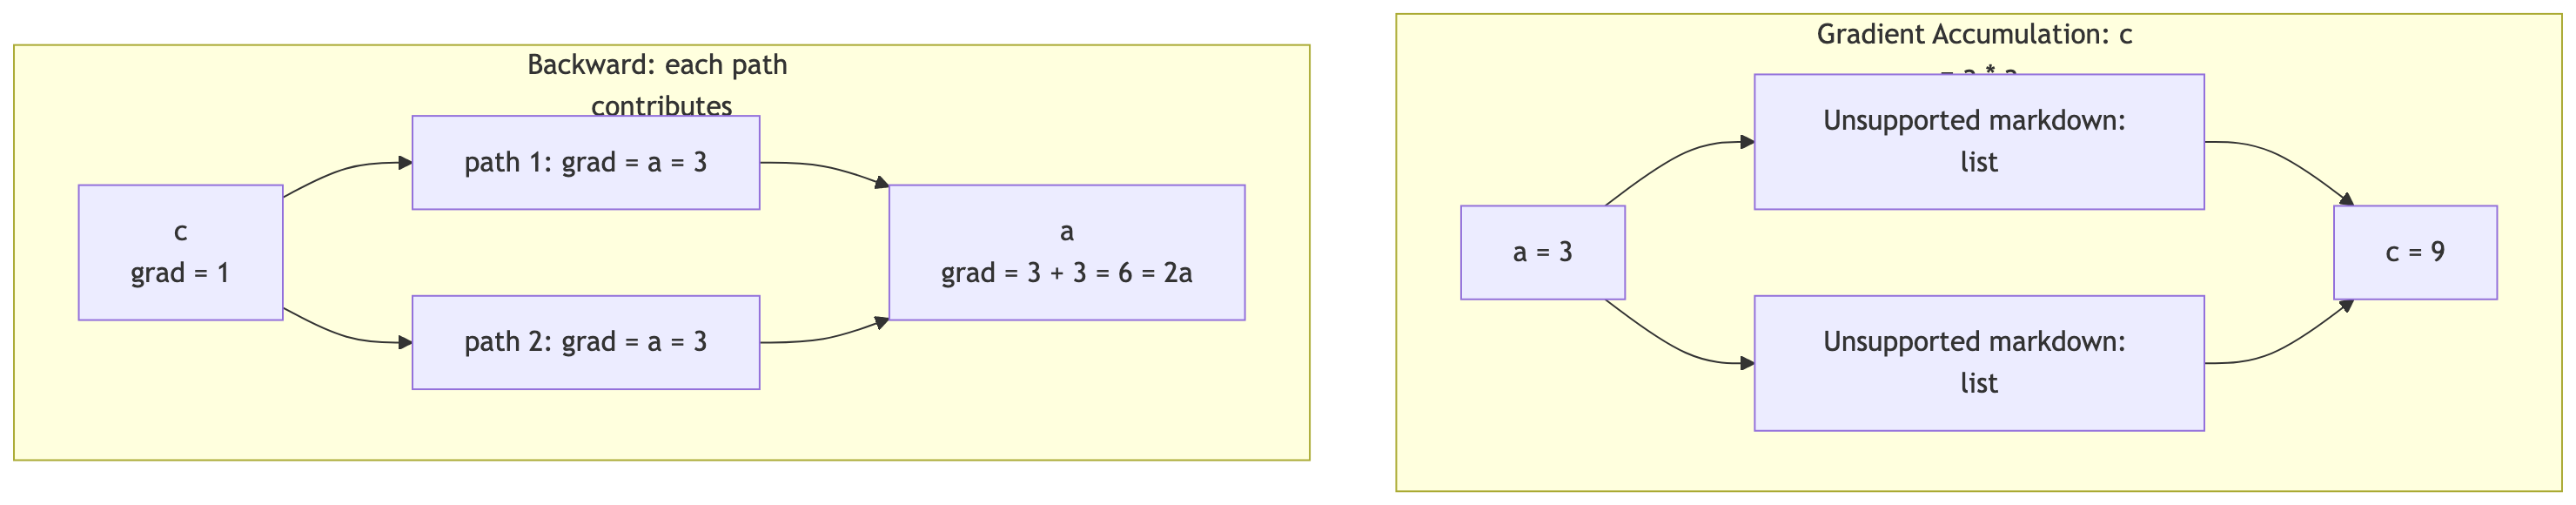

## Code Walkthrough

Let’s explore autograd interactively:

In [1]:
import torch

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.9.1

### Building a Simple Autograd Engine

We’ll build a simple autograd engine (inspired by Andrej Karpathy’s
micrograd). This handles scalar values only - PyTorch’s autograd extends
these same principles to tensors of any shape, which is what makes it
powerful for real neural networks.

In [2]:
class Value:
    """A scalar value that tracks its gradient."""

    def __init__(self, data, children=(), op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(children)
        self._op = op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad   # d(a+b)/da = 1
            other.grad += out.grad  # d(a+b)/db = 1
        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad  # d(a*b)/da = b
            other.grad += self.data * out.grad  # d(a*b)/db = a
        out._backward = _backward

        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers"
        out = Value(self.data ** other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __radd__(self, other):
        return self + other

    def __rmul__(self, other):
        return self * other

    def tanh(self):
        import math
        t = math.tanh(self.data)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t ** 2) * out.grad
        out._backward = _backward

        return out

    def relu(self):
        out = Value(max(0, self.data), (self,), 'relu')

        def _backward():
            self.grad += (self.data > 0) * out.grad
        out._backward = _backward

        return out

    def exp(self):
        import math
        out = Value(math.exp(self.data), (self,), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out

    def log(self):
        import math
        out = Value(math.log(self.data), (self,), 'log')

        def _backward():
            self.grad += (1.0 / self.data) * out.grad
        out._backward = _backward

        return out

    def __truediv__(self, other):
        return self * (other ** -1)

    def backward(self):
        # Topological sort to process in correct order
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # Go backwards, applying chain rule
        self.grad = 1.0
        for v in reversed(topo):
            v._backward()

### Testing Our Value Class

In [3]:
# Create some Values
a = Value(2.0, label='a')
b = Value(3.0, label='b')

print(f"a = {a}")
print(f"b = {b}")
print(f"\nInitially, gradients are 0.0")

a = Value(data=2.0, grad=0.0)
b = Value(data=3.0, grad=0.0)

Initially, gradients are 0.0

In [4]:
# Perform a computation
c = a * b
c.label = 'c'

print(f"c = a * b = {c.data}")
print(f"\nNow let's compute gradients with backward():")

c.backward()

print(f"\ndc/da = {a.grad}  (should be b = 3.0)")
print(f"dc/db = {b.grad}  (should be a = 2.0)")

c = a * b = 6.0

Now let's compute gradients with backward():

dc/da = 3.0  (should be b = 3.0)
dc/db = 2.0  (should be a = 2.0)

### Verifying Gradients Numerically

In [5]:
# Let's verify: increase 'a' by a tiny amount
epsilon = 0.0001

a_original = 2.0
b_val = 3.0

c_original = a_original * b_val
c_perturbed = (a_original + epsilon) * b_val

numerical_gradient = (c_perturbed - c_original) / epsilon

print(f"Numerical gradient dc/da = {numerical_gradient:.4f}")
print(f"Our computed gradient: {a.grad}")
print(f"\nThey match! (The tiny difference is numerical precision)")

Numerical gradient dc/da = 3.0000
Our computed gradient: 3.0

They match! (The tiny difference is numerical precision)

### The Chain Rule in Action

In [6]:
# Let's trace through: c = (a + b) * b
a = Value(2.0, label='a')
b = Value(3.0, label='b')

sum_ab = a + b
sum_ab.label = 'sum'
c = sum_ab * b
c.label = 'c'

c.backward()

print(f"Expression: c = (a + b) * b")
print(f"a = {a.data}, b = {b.data}")
print(f"sum = a + b = {sum_ab.data}")
print(f"c = sum * b = {c.data}")
print(f"\nGradients:")
print(f"dc/da = {a.grad}  (expected: b = 3)")
print(f"dc/db = {b.grad}  (expected: sum + a = 5 + 3 = 8)")

Expression: c = (a + b) * b
a = 2.0, b = 3.0
sum = a + b = 5.0
c = sum * b = 15.0

Gradients:
dc/da = 3.0  (expected: b = 3)
dc/db = 8.0  (expected: sum + a = 5 + 3 = 8)

### Training a Neuron

Let’s actually train a neuron to output a target value!

In [7]:
import matplotlib.pyplot as plt

# Training loop
x_val = 2.0
target_val = 0.8

# Learnable parameters (start with small random values)
w = 0.3
b = 0.1

learning_rate = 0.5
losses = []

print("Training a neuron to output 0.8 when input is 2.0")
print("=" * 50)

for step in range(20):
    # Create fresh Values (gradients reset)
    x = Value(x_val, label='x')
    w_v = Value(w, label='w')
    b_v = Value(b, label='b')
    target = Value(target_val, label='target')

    # Forward pass
    y = (w_v * x + b_v).tanh()
    loss = (y - target) ** 2

    # Backward pass
    loss.backward()

    # Gradient descent update
    w = w - learning_rate * w_v.grad
    b = b - learning_rate * b_v.grad

    losses.append(loss.data)

    if step % 4 == 0:
        print(f"Step {step:2d}: y={y.data:.4f}, loss={loss.data:.6f}, w={w:.4f}, b={b:.4f}")

print(f"\nFinal output: {y.data:.4f}")
print(f"Target: {target_val}")
print("Pretty close!")

Training a neuron to output 0.8 when input is 2.0
Step  0: y=0.6044, loss=0.038272, w=0.5484, b=0.2242
Step  4: y=0.8121, loss=0.000146, w=0.4650, b=0.1825
Step  8: y=0.8002, loss=0.000000, w=0.4595, b=0.1798
Step 12: y=0.8000, loss=0.000000, w=0.4594, b=0.1797
Step 16: y=0.8000, loss=0.000000, w=0.4594, b=0.1797

Final output: 0.8000
Target: 0.8
Pretty close!

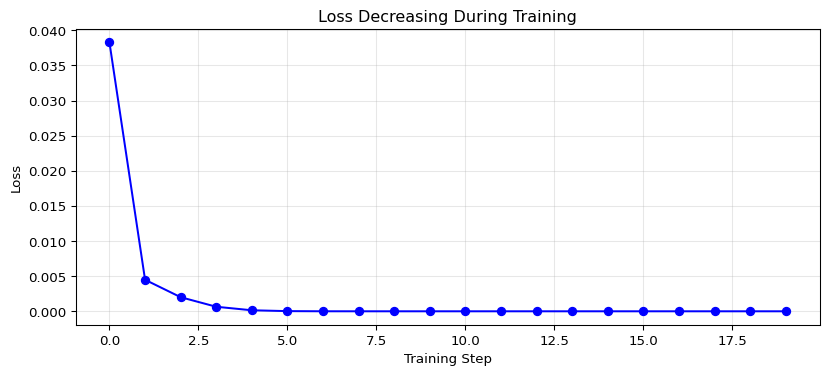


The loss decreases because gradients tell us which way to adjust w and b!

In [8]:
# Visualize the training
plt.figure(figsize=(10, 4))
plt.plot(losses, 'b-o')
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.title('Loss Decreasing During Training')
plt.grid(True, alpha=0.3)
plt.show()

print("\nThe loss decreases because gradients tell us which way to adjust w and b!")

### PyTorch Autograd

Now let’s see how PyTorch does the same thing:

In [9]:
# Create tensors that track gradients
x = torch.tensor(2.0, requires_grad=True)
w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

# Forward pass
y = w * x + b    # Linear function
loss = y ** 2    # Square loss

# Backward pass - PyTorch computes all gradients automatically
loss.backward()

print(f"dloss/dx = {x.grad}")  # 84.0
print(f"dloss/dw = {w.grad}")  # 56.0
print(f"dloss/db = {b.grad}")  # 14.0

dloss/dx = 42.0
dloss/dw = 28.0
dloss/db = 14.0

In [10]:
# With vectors
x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
w = torch.tensor([0.1, 0.2, 0.3], requires_grad=True)

# Forward pass
y = (x * w).sum()  # Dot product
print(f"y = x . w = {y.item():.4f}")

# Backward pass
y.backward()

print(f"\ndy/dx = {x.grad}")  # Should be w
print(f"dy/dw = {w.grad}")  # Should be x

y = x . w = 1.4000

dy/dx = tensor([0.1000, 0.2000, 0.3000])
dy/dw = tensor([1., 2., 3.])

In [11]:
# With matrices (like in attention)
Q = torch.randn(2, 3, requires_grad=True)  # Query
K = torch.randn(2, 3, requires_grad=True)  # Key

# Attention scores: Q @ K^T
scores = Q @ K.T
loss = scores.sum()

loss.backward()

print(f"Q shape: {Q.shape}")
print(f"K shape: {K.shape}")
print(f"scores shape: {scores.shape}")
print(f"\ndloss/dQ shape: {Q.grad.shape}")
print(f"dloss/dK shape: {K.grad.shape}")
print("\nGradients have the same shape as the original tensors!")

Q shape: torch.Size([2, 3])
K shape: torch.Size([2, 3])
scores shape: torch.Size([2, 2])

dloss/dQ shape: torch.Size([2, 3])
dloss/dK shape: torch.Size([2, 3])

Gradients have the same shape as the original tensors!

## Exercises

### Exercise 1: Verify the Gradient of x^3

In [12]:
# Verify the gradient of x^3 at x=2
# Expected: d/dx[x^3] = 3x^2 = 12

x = Value(2.0, label='x')
y = x ** 3
y.backward()

print(f"x = {x.data}")
print(f"y = x^3 = {y.data}")
print(f"dy/dx = {x.grad} (expected: 12.0)")

x = 2.0
y = x^3 = 8.0
dy/dx = 12.0 (expected: 12.0)

### Exercise 2: Softmax Gradient

In [13]:
# Compute gradient of softmax numerator
# If y = exp(x) / (exp(x) + exp(z)), what is dy/dx?

x = Value(1.0, label='x')
z = Value(2.0, label='z')

exp_x = x.exp()
exp_z = z.exp()
y = exp_x / (exp_x + exp_z)

y.backward()

print(f"x = {x.data}, z = {z.data}")
print(f"y = softmax(x)[0] = {y.data:.4f}")
print(f"dy/dx = {x.grad:.4f}")
print(f"\nThis is the gradient that flows back through softmax!")

x = 1.0, z = 2.0
y = softmax(x)[0] = 0.2689
dy/dx = 0.1966

This is the gradient that flows back through softmax!

### Exercise 3: ReLU vs Tanh Gradients

In [14]:
# Compare ReLU vs tanh gradients

for x_val in [-2.0, -0.5, 0.5, 2.0]:
    x_relu = Value(x_val)
    x_tanh = Value(x_val)

    y_relu = x_relu.relu()
    y_tanh = x_tanh.tanh()

    y_relu.backward()
    y_tanh.backward()

    print(f"x={x_val:5.1f}: ReLU grad={x_relu.grad:.3f}, tanh grad={x_tanh.grad:.3f}")

print("\nNotice: ReLU has 0 or 1, tanh is smooth but saturates for large |x|")

x= -2.0: ReLU grad=0.000, tanh grad=0.071
x= -0.5: ReLU grad=0.000, tanh grad=0.786
x=  0.5: ReLU grad=1.000, tanh grad=0.786
x=  2.0: ReLU grad=1.000, tanh grad=0.071

Notice: ReLU has 0 or 1, tanh is smooth but saturates for large |x|

## Backpropagation in Neural Networks

Here’s how gradients flow backward through a neural network layer:

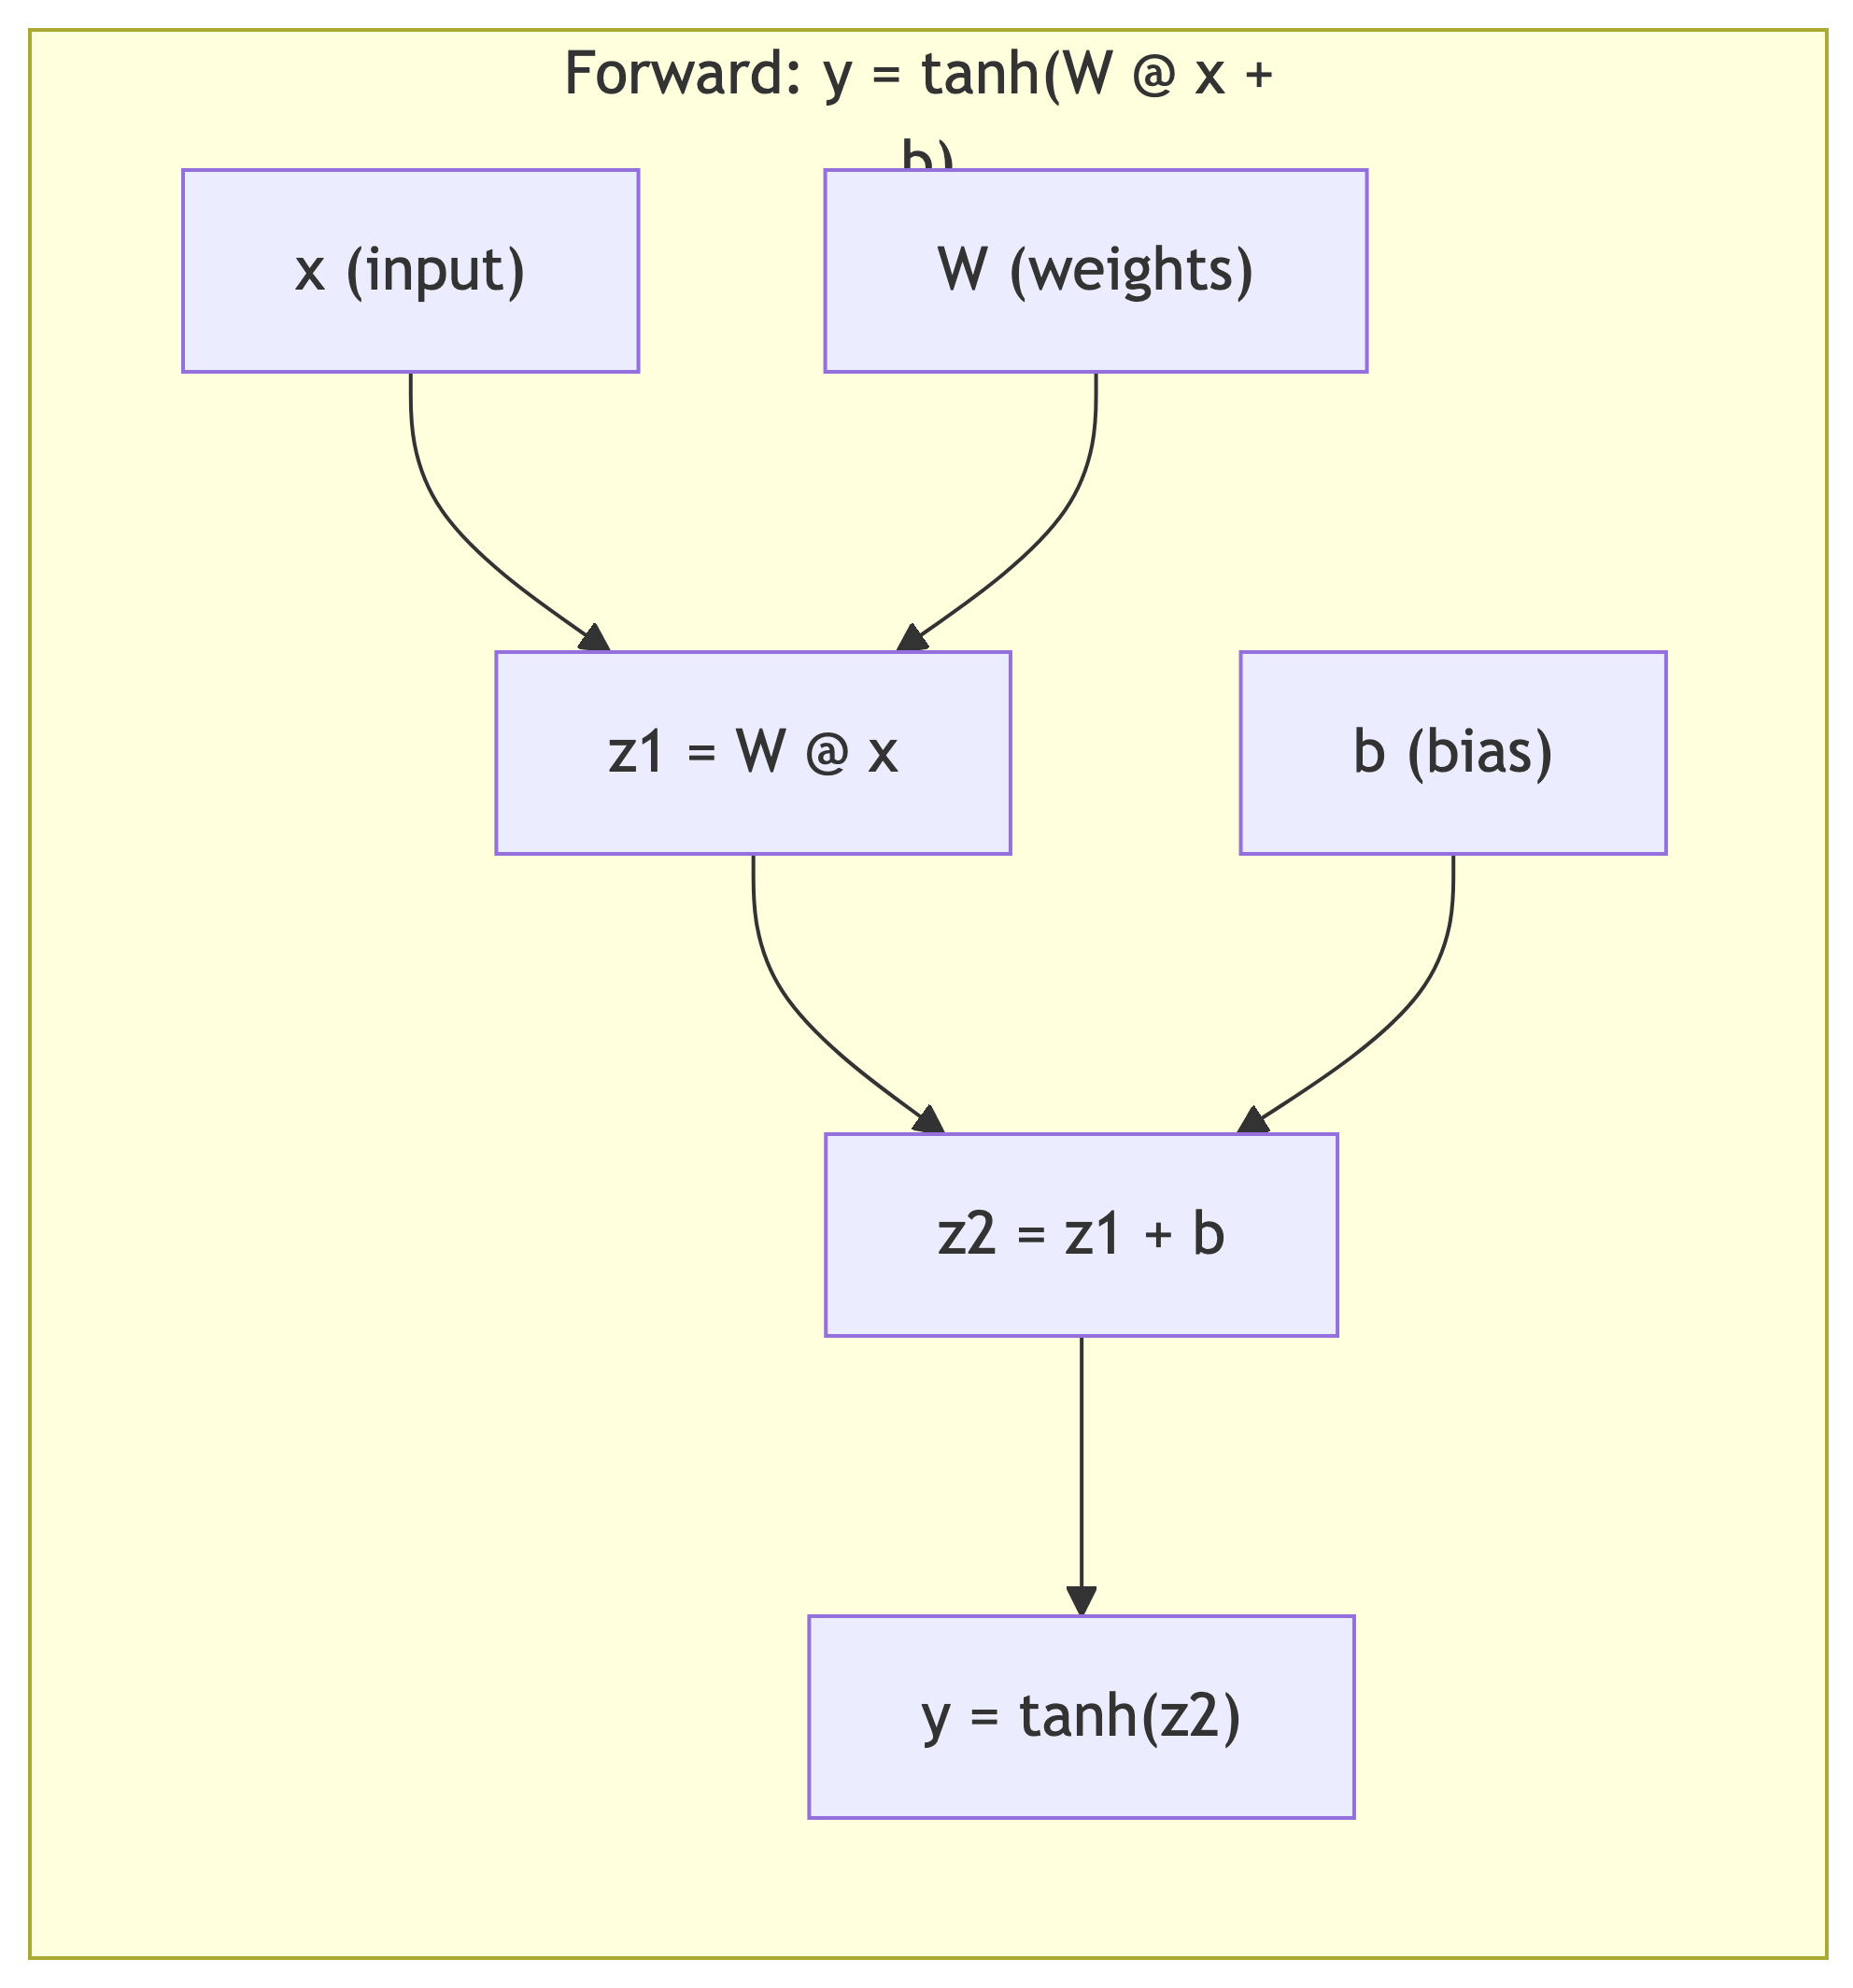

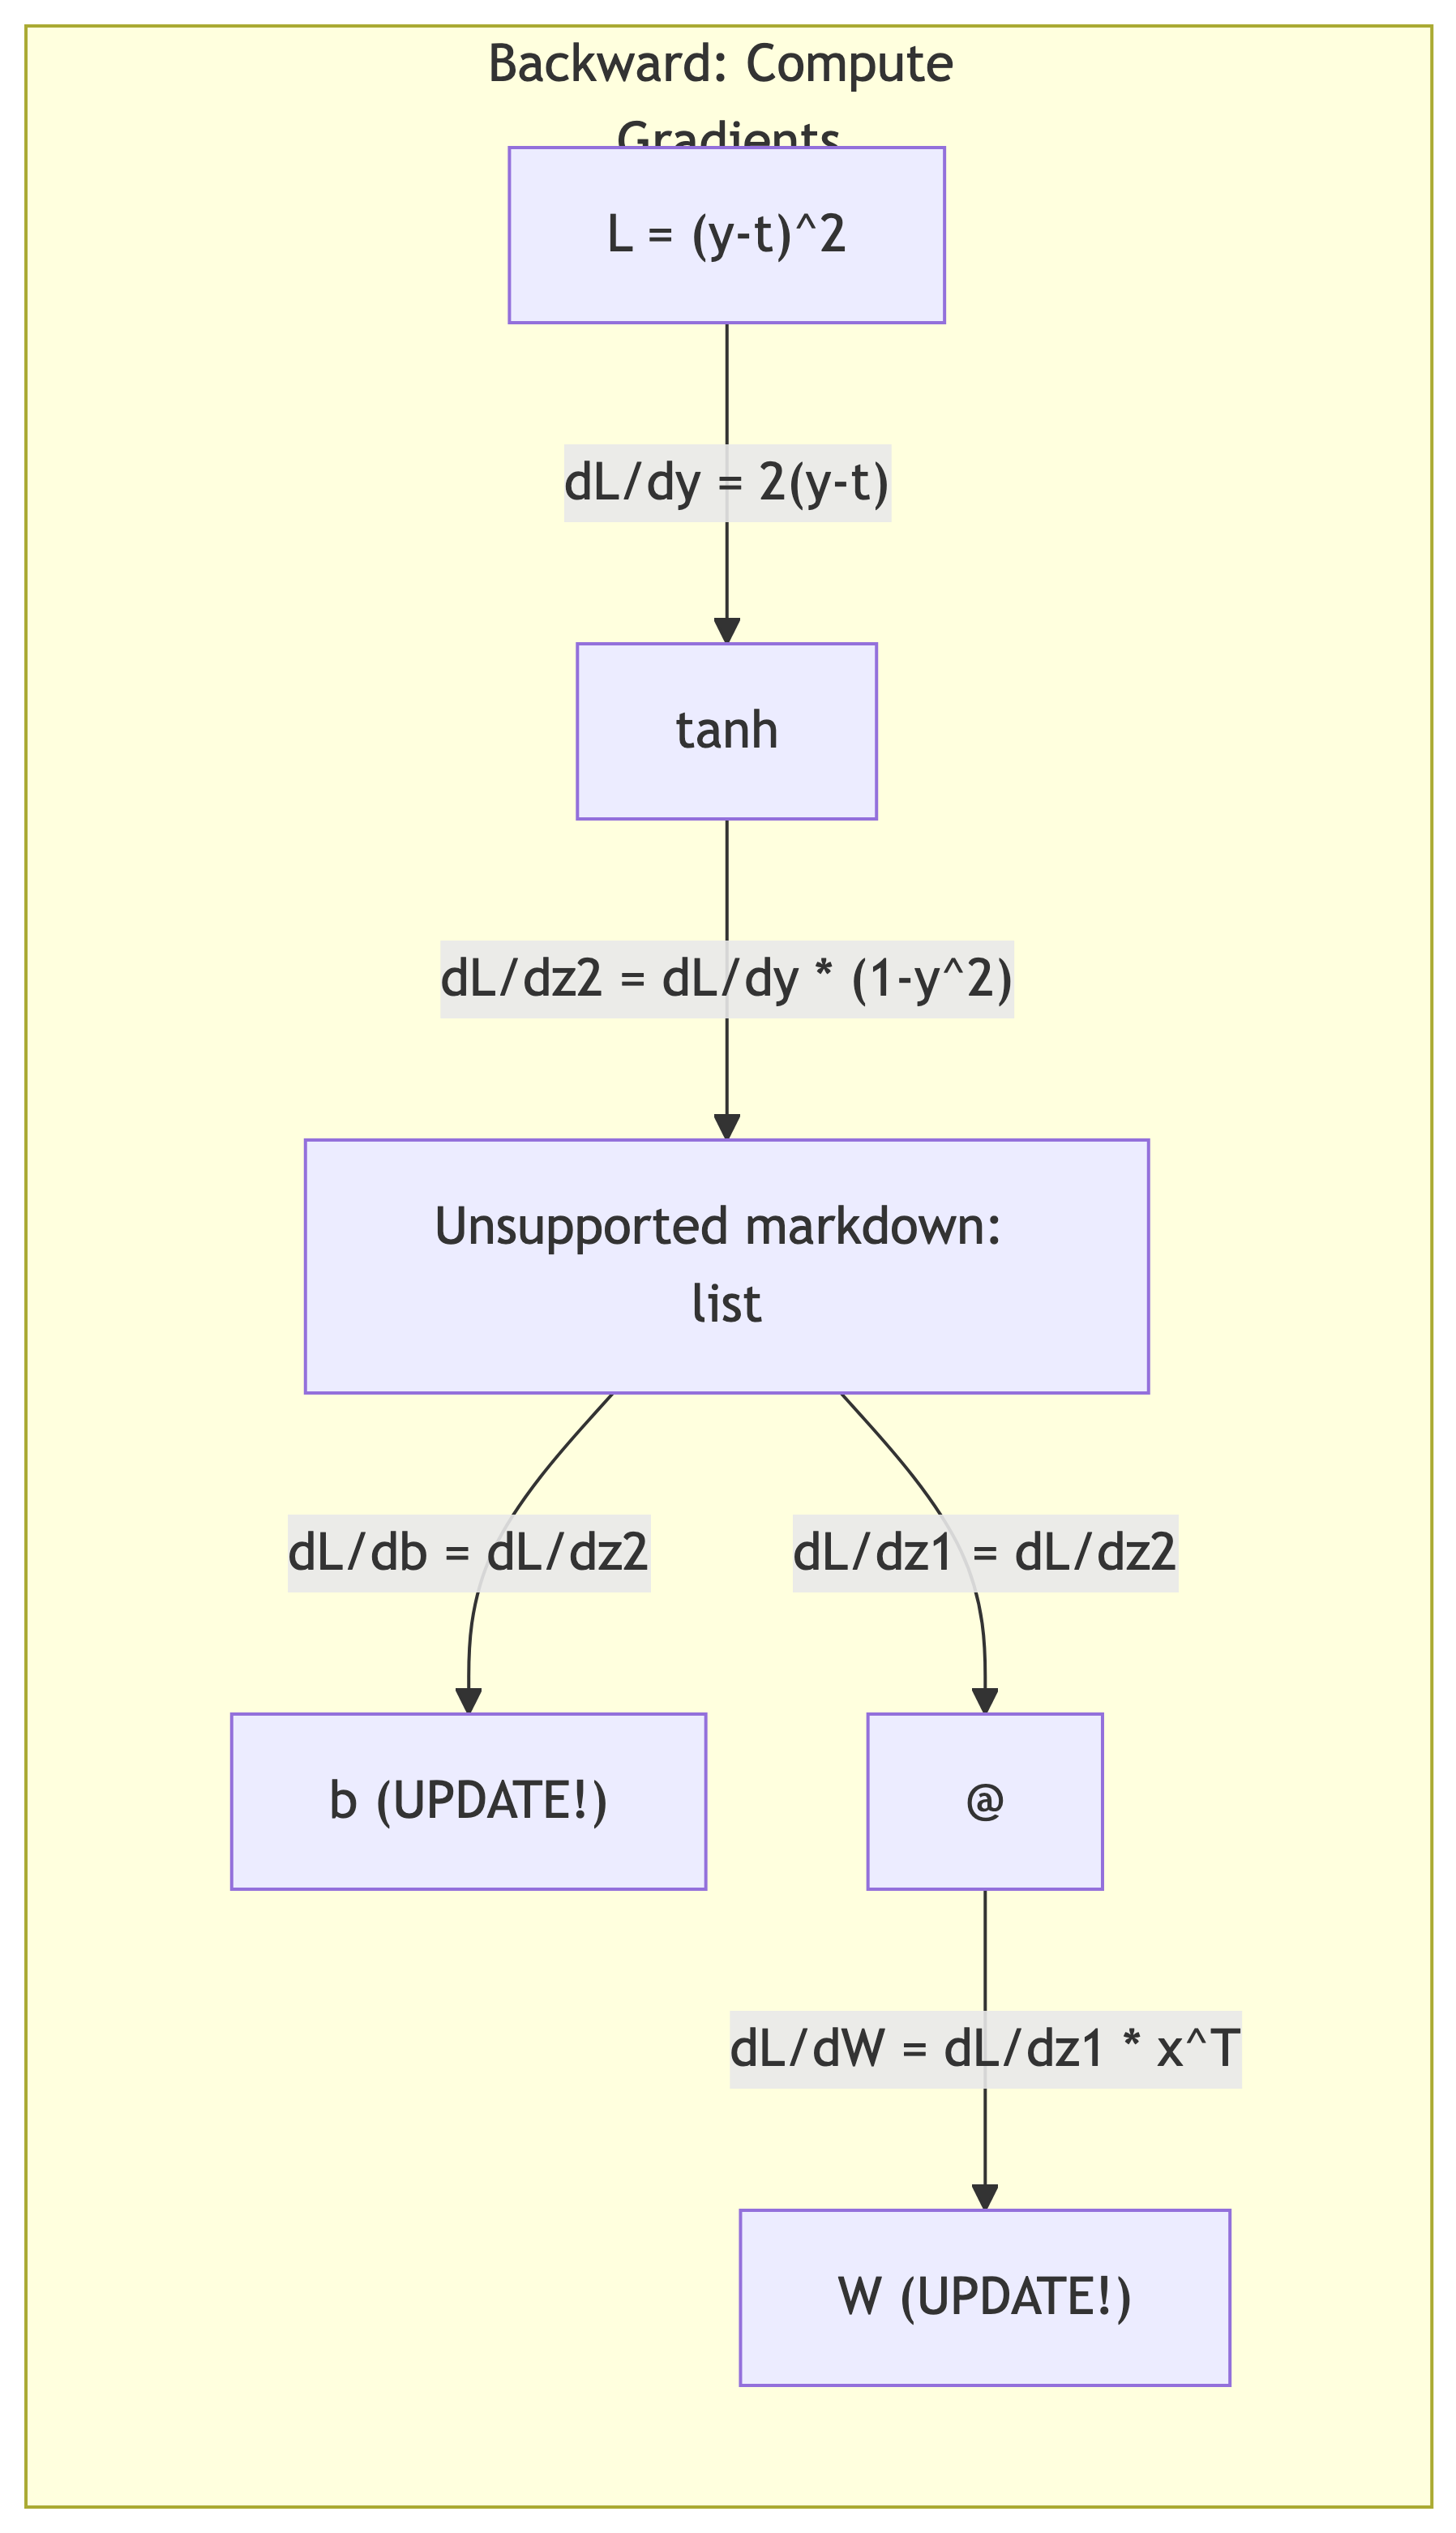

Key insights:

1.  **Gradients flow backward**: Starting from the loss, we trace back
    through every operation
2.  **Chain rule connects layers**: Multiply local gradients along the
    path
3.  **Accumulation**: If a value is used multiple times, gradients add
    up
4.  **Shape matters**: dL/dW must have the same shape as W for the
    update

## Detaching Tensors and Stopping Gradients

Sometimes you want to stop gradient flow. PyTorch provides several
mechanisms:

### Using detach()

In [15]:
x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
y = x * 2
z = y.detach()  # z has no gradient history

print(f"y.requires_grad: {y.requires_grad}")
print(f"z.requires_grad: {z.requires_grad}")

# z is now a "constant" - no gradients flow through it
loss = z.sum()
# loss.backward() would NOT compute gradients for x

y.requires_grad: True
z.requires_grad: False

### Using no_grad()

In [16]:
x = torch.tensor([1.0, 2.0], requires_grad=True)
y = x * 2

# Compute without building graph (saves memory)
with torch.no_grad():
    z = y * 3
    print(f"Inside no_grad, z.requires_grad: {z.requires_grad}")

# Common use: inference
model_output = y  # pretend this is model output
with torch.no_grad():
    prediction = model_output.argmax()  # no gradients needed

Inside no_grad, z.requires_grad: False

### When to Stop Gradients

-   **Inference**: No training, no gradients needed
-   **Frozen layers**: Transfer learning with some layers fixed
-   **Metrics**: Computing accuracy, loss for logging (not backprop)
-   **Target values**: In losses like MSE, the target is a constant

## Memory Implications

### Why Autograd Uses Memory

During the forward pass, autograd stores intermediate values needed for
gradient computation:

In [17]:
# Each operation stores data for backward pass
x = torch.randn(1000, 1000, requires_grad=True)
y = x @ x.T          # Stores x for gradient computation
z = y.relu()         # Stores y (to know which elements > 0)
out = z.mean()       # Stores z

# All of x, y, z stay in memory until backward() completes
out.backward()

# Now intermediate tensors can be freed

### Memory Grows with Depth

For a model with L layers: - Forward pass: O(L) memory for activations -
Each activation tensor can be large (batch_size x hidden_dim) - LLMs
with 100+ layers and large hidden dims = huge memory

### Gradient Checkpointing

Trade compute for memory by recomputing activations during backward:

In [18]:
from torch.utils.checkpoint import checkpoint

def expensive_layer(x):
    """A layer we want to checkpoint."""
    return x.relu().pow(2)

x = torch.randn(100, 100, requires_grad=True)

# Without checkpointing: stores intermediate activations
y_normal = expensive_layer(x)

# With checkpointing: discards intermediates, recomputes during backward
y_checkpoint = checkpoint(expensive_layer, x, use_reentrant=False)

print(f"Both produce same result: {torch.allclose(y_normal, y_checkpoint)}")

Both produce same result: True

In practice, checkpoint every few layers to reduce memory by ~sqrt(L).

## Common Pitfalls

### 1. Forgetting to Zero Gradients

In [19]:
x = torch.tensor(2.0, requires_grad=True)

# First backward
y = x ** 2
y.backward()
print(f"After first backward: x.grad = {x.grad}")

# Second backward without zeroing - gradients ACCUMULATE!
y = x ** 2
y.backward()
print(f"After second backward: x.grad = {x.grad}")  # 8.0, not 4.0!

# Always zero gradients before backward in training loops
x.grad.zero_()
y = x ** 2
y.backward()
print(f"After zeroing: x.grad = {x.grad}")  # Back to 4.0

After first backward: x.grad = 4.0
After second backward: x.grad = 8.0
After zeroing: x.grad = 4.0

### 2. In-place Operations

In [20]:
x = torch.tensor([1.0, 2.0], requires_grad=True)
y = x * 2

# This would break the graph (commented to avoid error):
# y.add_(1)  # In-place operation on a tensor needed for gradient

# Instead, use out-of-place operations:
y = y + 1  # Creates new tensor, graph preserved
y.sum().backward()
print(f"x.grad: {x.grad}")

x.grad: tensor([2., 2.])

### 3. Losing requires_grad

In [21]:
x = torch.tensor([1.0, 2.0], requires_grad=True)

# Can't call .numpy() directly on a tensor requiring grad:
# y = x.numpy()  # RuntimeError: Can't call numpy() on tensor that requires grad

# Must detach first - this explicitly breaks the graph
y = x.detach().numpy()
print(f"y is now numpy array: {type(y)}")

# Converting back loses gradient tracking:
z = torch.from_numpy(y)
print(f"z.requires_grad: {z.requires_grad}")  # False

# Be careful when mixing numpy and autograd

y is now numpy array: <class 'numpy.ndarray'>
z.requires_grad: False

### 4. Backward Through Non-Scalar

In [22]:
x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
y = x ** 2  # Vector output

# This fails (commented to avoid error):
# y.backward()  # RuntimeError: need gradient argument

# For non-scalar outputs, provide a gradient tensor:
y.backward(torch.ones_like(y))  # Equivalent to y.sum().backward()
print(f"x.grad: {x.grad}")

x.grad: tensor([2., 4., 6.])

## Summary

Key takeaways:

1.  **Gradients flow backward** through the computational graph
2.  **Chain rule** connects everything: multiply local gradients
3.  **Gradients accumulate** when a value is used multiple times
4.  **Training = gradient descent**: use gradients to adjust parameters
5.  **PyTorch autograd** does this automatically for any computation
6.  **Memory matters**: intermediate activations consume memory; use
    `detach()`, `no_grad()`, or gradient checkpointing
7.  **Zero gradients**: always zero gradients before each backward pass
    in training loops

## What’s Next

In [Module 03: Tokenization](../m03_tokenization/lesson.qmd), we’ll
learn how text gets converted into numbers that our model can process.
Autograd will be working behind the scenes during training, but we need
input data first!